In [10]:
# -*- coding: utf-8 -*-
"""
Plots for:
1) 1D sensitivity axis using normalized sensitivities:
   position = norm - direction, where norm + direction = 1
   left end [-1] = [0,1] (direction-only), center [0] = [0.5,0.5], right end [+1] = [1,0] (norm-only)
2) Radar chart of normalized median α per region (R1..R4)

Outputs are saved to ./plots as PNGs.
"""
import json
import os
import matplotlib.pyplot as plt
import numpy as np

# =========================================
# Prefer loading from your JSON files
# =========================================
file_map = {
    "FedAvg":    "/mnt/data/fedavg_pref_summary.json",
    "FLAME":     "/mnt/data/flame_pref_summary.json",
    "FLTrust":   "/mnt/data/fltrust_pref_summary.json",
    "RFA":       "/mnt/data/rfa_pref_summary.json",
    "Krum":      "/mnt/data/krum_pref_summary.json",
    "Median":    "/mnt/data/median_pref_summary.json",
    "NormBound": "/mnt/data/normbound_pref_summary.json",
}

# Fallback inline datasets (used only if a file is missing)
inline_data = {
    "FedAvg": {
        "agg_rule_inference": {
            "sensitivity": {"norm": 0.9061726511037835, "direction": 0.09382734889621651},
            "beta_raw": {"intercept": 0.08210578569764172, "beta_norm": 0.035368638255539576, "beta_dir": -0.003662155945166029},
        },
        "per_region": {"1": {"normalized_median_alpha": 0.07522793610890706},
                       "2": {"normalized_median_alpha": 0.09935639301935832},
                       "3": {"normalized_median_alpha": 0.08816500504811604},
                       "4": {"normalized_median_alpha": 0.09953938921292622}}
    },
    "FLAME": {
        "agg_rule_inference": {
            "sensitivity": {"norm": 0.9130495805078023, "direction": 0.0869504194921977},
            "beta_raw": {"intercept": 0.17468013606658303, "beta_norm": -0.21375628517344664, "beta_dir": -0.020356176774746573},
        },
        "per_region": {"1": {"normalized_median_alpha": 0.14892072478930157},
                       "2": {"normalized_median_alpha": 0.0},
                       "3": {"normalized_median_alpha": 0.1670702894528707},
                       "4": {"normalized_median_alpha": 0.0}}
    },
    "FLTrust": {
        "agg_rule_inference": {
            "sensitivity": {"norm": 0.2682044008969735, "direction": 0.7317955991030265},
            "beta_raw": {"intercept": 0.014860769879517363, "beta_norm": 0.012575139952859185, "beta_dir": 0.034311264262743994},
        },
        "per_region": {"1": {"normalized_median_alpha": 0.016935506835579872},
                       "2": {"normalized_median_alpha": 0.008979532246788343},
                       "3": {"normalized_median_alpha": 0.011281459592282772},
                       "4": {"normalized_median_alpha": 0.0006440972210839391}}
    },
    "RFA": {
        "agg_rule_inference": {
            "sensitivity": {"norm": 0.7260445547443635, "direction": 0.27395544525563653},
            "beta_raw": {"intercept": 0.08685021058750667, "beta_norm": -0.1005201321158304, "beta_dir": 0.03792885349941606},
        },
        "per_region": {"1": {"normalized_median_alpha": 0.16820730765660602},
                       "2": {"normalized_median_alpha": 0.045279751221338906},
                       "3": {"normalized_median_alpha": 0.0657082994778951},
                       "4": {"normalized_median_alpha": 0.03681497400005658}}
    },
    "Krum": {
        "agg_rule_inference": {
            "sensitivity": {"norm": 0.8405685275989984, "direction": 0.15943147240100158},
            "beta_raw": {"intercept": 0.047142104038708506, "beta_norm": -0.03225442057726945, "beta_dir": 0.006117728174719922},
        },
        "per_region": {"1": {"normalized_median_alpha": 0.004359230088690917},
                       "2": {"normalized_median_alpha": 0.0},
                       "3": {"normalized_median_alpha": 0.006495118141174316},
                       "4": {"normalized_median_alpha": 0.0}}
    },
    "Median": {
        "agg_rule_inference": {
            "sensitivity": {"norm": 0.8849696920601036, "direction": 0.11503030793989649},
            "beta_raw": {"intercept": 0.07574914880925615, "beta_norm": -0.0751536482673397, "beta_dir": 0.009768636576552527},
        },
        "per_region": {"1": {"normalized_median_alpha": 0.10566556453704834},
                       "2": {"normalized_median_alpha": 0.03565208613872528},
                       "3": {"normalized_median_alpha": 0.0526577482620875},
                       "4": {"normalized_median_alpha": 0.032374913493792214}}
    },
    "NormBound": {
        "agg_rule_inference": {
            "sensitivity": {"norm": 0.6367468320094691, "direction": 0.3632531679905309},
            "beta_raw": {"intercept": 0.04452737996655286, "beta_norm": 0.06290671546497152, "beta_dir": 0.03588720435155617},
        },
        "per_region": {"1": {"normalized_median_alpha": 0.09018869201342265},
                       "2": {"normalized_median_alpha": 0.09970024724801381},
                       "3": {"normalized_median_alpha": 0.030903590222199757},
                       "4": {"normalized_median_alpha": 0.09960344433784485}}
    }
}

def load_rule_json(path):
    with open(path, "r") as f:
        return json.load(f)

def get_rule_data(rule):
    """Load from file if present; otherwise fall back to inline_data."""
    path = file_map[rule]
    if os.path.exists(path):
        try:
            return load_rule_json(path)
        except Exception:
            pass
    return inline_data[rule]

# Load everything into a unified structure
json_data = {rule: get_rule_data(rule) for rule in file_map.keys()}

# =============================================
# Extract normalized sensitivities and regions
# =============================================
# Sensitivity (normalized per rule) for the 1D axis
sensitivity_normed = {
    rule: (
        d["agg_rule_inference"]["sensitivity"]["norm"],
        d["agg_rule_inference"]["sensitivity"]["direction"],
    )
    for rule, d in json_data.items()
}

# Region values for radar (normalized_median_alpha)
region_data = {
    rule: [d["per_region"][str(i)]["normalized_median_alpha"] for i in range(1, 4 + 1)]
    for rule, d in json_data.items()
}

# ================================
# Colors/markers (colorblind-safe)
# ================================
colors = {
    "FedAvg":    "#1f77b4",  # blue
    "FLAME":     "#ff7f0e",  # orange
    "FLTrust":   "#2ca02c",  # green
    "RFA":       "#d62728",  # red
    "Krum":      "#9467bd",  # purple
    "Median":    "#8c564b",  # brown
    "NormBound": "#e377c2",  # magenta
}
edge_colors = {

        "FedAvg":    "#1f77b4",
        "FLAME":     "#ff7f0e",
        "FLTrust":   "#2ca02c",
        "RFA":       "#d62728",
        "Krum":      "#9467bd",
        "Median":    "#8c564b",
        "NormBound": "#e377c2",
    
}
markers = {
    "FedAvg": "o",
    "FLAME": "s",
    "FLTrust": "^",
    "RFA": "D",
    "Krum": "p",
    "Median": "*",
    "NormBound": "X",
}

# Ensure output dir
os.makedirs("plots", exist_ok=True)

# # =====================================
# # Plot 1: 1D sensitivity preference axis
# # =====================================
# plt.figure(figsize=(7.2, 2.2))
# ax = plt.gca()

# # Horizontal axis from -1 (direction-only) to +1 (norm-only)
# ax.axhline(0, color="#888888", linewidth=1.0)
# for x in (-1.0, 0.0, 1.0):
#     ax.axvline(x, color="#DDDDDD", linewidth=0.8, linestyle="--", zorder=0)

# # Compute scalar position: x = norm - direction (since norm+direction=1)
# # This maps [0,1] (dir) -> -1, [0.5,0.5] -> 0, [1,0] (norm) -> +1
# positions = {rule: (sn - sd) for rule, (sn, sd) in sensitivity_normed.items()}

# # Slight vertical offsets to reduce label overlap around y=0
# offsets = np.linspace(0.06, -0.06, num=len(positions))
# for (rule, x), dy in zip(sorted(positions.items(), key=lambda kv: kv[1]), offsets):
#     ax.scatter(x, 0.0, s=140, color=colors[rule], edgecolor="black",
#                linewidth=0.6, marker=markers[rule], alpha=0.9, zorder=3)
#     # Label just above/below the axis
#     ax.text(x, dy, rule, ha="center", va="center", fontsize=10, color=colors[rule])

# # Axis formatting
# ax.set_xlim(-1.05, 1.05)
# ax.set_ylim(-0.2, 0.2)
# ax.set_yticks([])
# ax.set_xlabel("Sensitivity preference axis  (−1: [0,1] dir-only  ·  0: [0.5,0.5] balanced  ·  +1: [1,0] norm-only)", fontsize=11)
# ax.set_xticks([-1.0, -0.5, 0.0, 0.5, 1.0])
# ax.set_xticklabels(["−1", "−0.5", "0", "0.5", "1"], fontsize=10)
# plt.tight_layout()
# plt.savefig("plots/sensitivity_1d.png", dpi=220, bbox_inches="tight")
# plt.close()

# ==============================
# Plot 2: Radar for per-region α
# ==============================
def radar_plot(ax, angles, values, color, edgecolor, label, face_alpha=0.18, edge_alpha=0.9,
               linestyle='-', marker=None, markevery=None, linewidth=1.8):
    vals = np.concatenate((values, [values[0]]))
    angs = np.concatenate((angles, [angles[0]]))
    ax.plot(angs, vals, color=edgecolor, linewidth=linewidth, alpha=edge_alpha,
            linestyle=linestyle, marker=marker, markevery=markevery, label=label, zorder=3)
    ax.fill(angs, vals, color=color, alpha=face_alpha, edgecolor=edgecolor, linewidth=1.0, zorder=2)


# --- log-like radial warp (handles zeros) ---
def make_radial_warp(r_max, eps_frac=0.02):
    """
    Map r in [0, r_max] -> r' in [0, r_max] with a log-like stretch near zero.
    eps controls how strong the expansion near zero is.
    """
    eps = eps_frac * max(r_max, 1e-8)

    def warp(r):
        r = np.asarray(r)
        num = np.log(eps + r) - np.log(eps)
        den = np.log(eps + r_max) - np.log(eps)
        return (num / den) * r_max

    return warp


style_map = {
    "FedAvg":    {"linestyle": "-",          "marker": "o"},
    "FLAME":     {"linestyle": "-",         "marker": "o"},
    "FLTrust":   {"linestyle": "-",        "marker": "o"},
    "RFA":       {"linestyle": "-",          "marker": "o"},
    "Krum":      {"linestyle": "-",        "marker": "o"},
    "Median":    {"linestyle": "-",    "marker": "o"},
    "NormBound": {"linestyle": "-",    "marker": "o"},
}


# --- collect data range and build warp ---
all_vals = np.array([v for vals in region_data.values() for v in vals])
r_max_data = float(np.nanmax(all_vals)) if all_vals.size else 0.17
r_max = max(0.17, r_max_data * 1.05)  # keep your previous headroom
warp = make_radial_warp(r_max, eps_frac=0.04)  # increase eps_frac to exaggerate small values more

plt.figure(figsize=(5.6, 5.8))
ax = plt.subplot(111, polar=True)
angles = np.linspace(0, 2*np.pi, 4, endpoint=False)


# --- highlight the 0.10 circle (gridline) ---
highlight_val = 0.10
highlight_r = warp(highlight_val)

# ticks: show original (unwarped) values as labels at warped positions
# ticks: show original (unwarped) values as labels at warped positions
base_ticks = [0.01, 0.05, 0.10]
tick_vals = [t for t in base_ticks if t <= r_max]

# always append the actual outer limit
tick_vals.append(r_max)

tick_pos = warp(np.array(tick_vals))
ax.set_yticks(tick_pos)
ax.set_yticklabels([f"{t:.02f}" for t in tick_vals], color="grey", fontsize=10)


ax.set_rlabel_position(45)

# force creation of gridline artists
ax.figure.canvas.draw()

# find the gridline closest to the warped 0.10 and restyle it
lines = ax.yaxis.get_gridlines()
yticks_drawn = ax.get_yticks()  # these are the warped positions
idx = int(np.argmin(np.abs(yticks_drawn - highlight_r)))

hl = lines[idx]
hl.set_color("royalblue")
hl.set_linestyle("--")   # dotted/dashed
hl.set_linewidth(1.6)
hl.set_alpha(0.95)

# (optional) also color the 0.10 tick label
labels = ax.get_yticklabels()
labels[idx].set_color("royalblue")
# labels[idx].set_fontweight("bold")


# angular ticks
ax.set_xticks(angles)
ax.set_xticklabels([r'$\mathcal{R}_1$', r'$\mathcal{R}_2$', r'$\mathcal{R}_3$', r'$\mathcal{R}_4$'], fontsize=12)

# limits & grid behind data
ax.set_rlim(0, r_max)  # use warped coordinate range
ax.set_axisbelow(True)
ax.grid(alpha=0.35, linestyle='--', linewidth=0.8)

# ===  PLOT THE DATA ===
for rule, values in region_data.items():
    warped = warp(np.array(values, dtype=float))  # keep your existing warp
    st = style_map.get(rule, {})
    radar_plot(ax, angles, warped, colors[rule], edge_colors[rule], rule,
               face_alpha=0.00, edge_alpha=0.95,
               linestyle=st.get("linestyle", "-"),
               marker=st.get("marker", None),
               linewidth=1.9)


# legend at bottom, two rows (only if we have handles)
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.20),
              ncol=4, frameon=False, handlelength=1.8)

# layout & save (no plt.show())
plt.tight_layout(rect=[0.02, 0.06, 0.98, 1.0])
os.makedirs("plots", exist_ok=True)
plt.savefig("plots/region_radar.png", dpi=220, bbox_inches="tight")
plt.close()



In [28]:
def plot_norm_sensitivity_axis(
    sensitivity_normed,
    colors=None,
    markers=None,
    figsize=(7.0, 2.2),
    savepath=None,
    # --- routing controls ---
    min_dx=0.03,          # min spacing between label anchors (post-cluster)
    n_y_levels=3,         # how many vertical tiers for labels
    y_top=0.30,           # highest label tier
    y_bottom=0.12,        # lowest label tier
    curve_rad=0.18,       # curvature for connectors
    # --- cluster controls ---
    cluster_eps=0.015,    # points within this x-gap are considered one cluster
    fanout_step=0.022,    # horizontal spacing between labels inside a cluster
    manual_nudge=None,    # optional: dict {rule: dx} to force a small extra shift
):
    """
    Plots only σ_norm on [0,1] with overlap-aware label routing.

    New: cluster-aware fanout
      - Points whose x's differ by < cluster_eps are grouped.
      - Labels within a cluster are 'fanned out' horizontally around the cluster center
        with spacing = fanout_step, then curved connectors are drawn.
      - After fanout, a light global spacing pass (min_dx) is applied.

    manual_nudge: optional dict of per-rule x nudges (applied to label anchors only),
                  e.g., {'Krum': +0.012, 'FLAME': -0.010}
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import os

    # Defaults (colorblind-friendly)
    default_colors = {
        "FedAvg":    "#1f77b4",
        "FLAME":     "#ff7f0e",
        "FLTrust":   "#2ca02c",
        "RFA":       "#d62728",
        "Krum":      "#9467bd",
        "Median":    "#8c564b",
        "NormBound": "#e377c2",
    }
    default_markers = {
        "FedAvg": "o",
        "FLAME": "s",
        "FLTrust": "^",
        "RFA": "D",
        "Krum": "p",
        "Median": "*",
        "NormBound": "X",
    }
    if colors is None:  colors = default_colors
    if markers is None: markers = default_markers
    if manual_nudge is None: manual_nudge = {}

    rules = list(sensitivity_normed.keys())
    x_vals = np.array([sensitivity_normed[r]["norm"] for r in rules], dtype=float)

    fig, ax = plt.subplots(figsize=figsize)

    # Axis & ticks
    ax.axhline(0, color="black", linewidth=1.0)
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.1, max(0.44, y_top + 0.08))
    ax.set_yticks([])
    ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xticklabels([r"$0$", r"$0.25$", r"$0.5$", r"$0.75$", r"$1$"], fontsize=11)
    ax.set_xlabel(r"$\sigma_{\mathrm{norm}}$ (norm sensitivity)", fontsize=12)

    # Points
    for i, r in enumerate(rules):
        ax.plot(x_vals[i], 0, marker=markers.get(r, "o"), markersize=9,
                color=colors.get(r, "#333333"),
                markeredgecolor="black", markeredgewidth=0.5, zorder=3)

    # ---------------------------
    # 1) Make clusters by x-gap
    # ---------------------------
    order = np.argsort(x_vals)
    x_sorted = x_vals[order]
    r_sorted = [rules[i] for i in order]

    clusters = []
    current = [0]
    for i in range(1, len(x_sorted)):
        if (x_sorted[i] - x_sorted[i-1]) <= cluster_eps:
            current.append(i)
        else:
            clusters.append(current)
            current = [i]
    if current:
        clusters.append(current)

    # ---------------------------
    # 2) Fanout labels per cluster
    # ---------------------------
    anchors = np.zeros_like(x_sorted)
    for idxs in clusters:
        xs = x_sorted[idxs]
        center = float(xs.mean())  # cluster center at data x's
        m = len(idxs)
        if m == 1:
            anchors[idxs[0]] = center
        else:
            # Symmetric offsets around center, step=fanout_step
            # Example for m=4: offsets = [-1.5, -0.5, 0.5, 1.5] * fanout_step
            base = np.arange(m) - (m - 1) / 2.0
            # Slight staggering to avoid exact symmetry overlaps from different clusters
            offsets = base * fanout_step
            anchors[idxs] = center + offsets

    # Clamp anchors to [0,1]
    anchors = np.clip(anchors, 0.0, 1.0)

    # Optional manual nudges (fine-grained control)
    for i, r in enumerate(r_sorted):
        if r in manual_nudge:
            anchors[i] = float(np.clip(anchors[i] + manual_nudge[r], 0.0, 1.0))

    # -----------------------------------------
    # 3) Global light spacing pass (repulsion)
    # -----------------------------------------
    # Ensure minimum spacing min_dx between consecutive anchors
    for i in range(1, len(anchors)):
        if anchors[i] - anchors[i-1] < min_dx:
            need = min_dx - (anchors[i] - anchors[i-1])
            # push right if room; else pull left previous
            push = min(need, 1.0 - anchors[i])
            anchors[i] += push
            if push < need:  # not enough room on the right
                anchors[i-1] = max(0.0, anchors[i-1] - (need - push))

    # -----------------------------------------
    # 4) Assign vertical tiers (stagger labels)
    # -----------------------------------------
    y_levels = np.linspace(y_top, y_bottom, num=max(1, n_y_levels))
    # For more separation inside the same cluster, start tier from cluster index
    # Build a reverse map: index -> cluster_id
    cluster_id = {}
    for cid, idxs in enumerate(clusters):
        for j in idxs:
            cluster_id[j] = cid

    for i, (r, x, x_anchor) in enumerate(zip(r_sorted, x_sorted, anchors)):
        # tier: combine global order and cluster id to break patterns
        tier = (i + cluster_id.get(i, 0)) % len(y_levels)
        y = y_levels[tier]
        c = colors.get(r, "#333333")
        rad = curve_rad if (x_anchor >= x) else -curve_rad

        ax.annotate(
            r,
            xy=(x, 0), xytext=(x_anchor, y),
            textcoords='data',
            ha='center', va='center', fontsize=10, color=c,
            arrowprops=dict(
                arrowstyle='-',
                color=c, lw=1.2, alpha=0.95,
                shrinkA=0, shrinkB=0,
                connectionstyle=f'arc3,rad={rad}',
            ),
            zorder=4,
        )

    ax.set_axisbelow(True)
    ax.grid(axis="x", linestyle="--", alpha=0.3)

    plt.tight_layout()
    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=240, bbox_inches="tight")
    plt.show()


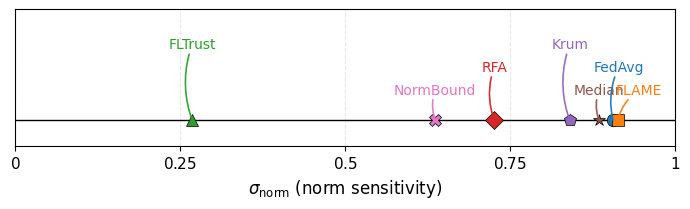

In [32]:
# ============================
# Example usage (in-memory)
# ============================
sensitivity_normed = {
    "FedAvg":    {"norm": 0.9061726511037835, "direction": 0.09382734889621651},
    "FLAME":     {"norm": 0.9130495805078023, "direction": 0.0869504194921977},
    "FLTrust":   {"norm": 0.2682044008969735, "direction": 0.7317955991030265},
    "RFA":       {"norm": 0.7260445547443635, "direction": 0.27395544525563653},
    "Krum":      {"norm": 0.8405685275989984, "direction": 0.15943147240100158},
    "Median":    {"norm": 0.8849696920601036, "direction": 0.11503030793989649},
    "NormBound": {"norm": 0.6367468320094691, "direction": 0.3632531679905309},
}
plot_norm_sensitivity_axis(sensitivity_normed, savepath=None)


In [74]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import os

def plot_dual_axis_rulers(
    sensitivity_normed,
    colors=None,
    figsize=(7.0, 2.4),
    savepath=None,
    # ---- band geometry (NARROWER/WIDER GAP BETWEEN RULERS) ----
    # Move these closer together to make the band narrower:
    ruler_y_bottom=0.28,   # bottom ruler y (0..1, increase to move up)
    ruler_y_top=0.72,      # top ruler y   (0..1, decrease to move down)
    # ---- bar geometry (BAR WIDTH / OVERLAP) ----
    bar_halfwidth=0.006,   # half-width of each vertical bar (increase for thicker)
    linewidth_ruler=1.4,
    tick_length=0.06,
    # ---- auto label routing ----
    min_dx=0.03,           # min spacing between label anchors on x (reduces collisions)
    label_y_top=0.64,      # highest tier for labels (below top ruler)
    label_y_bottom=0.36,   # lowest tier for labels (above bottom ruler)
    curve_rad=0.14,
    # ---- manual label controls ----
    # Optional: dict {"FedAvg": (x_anchor, y_anchor), ...} in data coords (x in [0,1], y in [0,1])
    # Use this to place any text exactly where you want, with a leader line to the bar.
    label_anchor_overrides=None,
    dpi=240,
):
    """
    Two horizontal 'rulers':
      - bottom x-axis: σ_norm in [0,1]
      - top x-axis:    σ_dir  in [1,0]
    Data bars span from bottom ruler to top ruler.
    Aggregation names are drawn with leader lines pointing to bars (acts as legend).

    IMPORTANT KNOBS:
      * Narrower band between rulers -> adjust ruler_y_bottom ↑ and ruler_y_top ↓
      * Bar thickness / overlap      -> adjust bar_halfwidth
      * Manual label placement       -> label_anchor_overrides={'FedAvg': (0.90, 0.60), ...}
    """
    # Consistent paper colors
    default_colors = {
        "FedAvg":    "#1f77b4",
        "FLAME":     "#ff7f0e",
        "FLTrust":   "#2ca02c",
        "RFA":       "#d62728",
        "Krum":      "#9467bd",
        "Median":    "#8c564b",
        "NormBound": "#e377c2",
    }
    if colors is None:
        colors = default_colors
    if label_anchor_overrides is None:
        label_anchor_overrides = {}

    rules = list(sensitivity_normed.keys())
    x_norm = np.array([sensitivity_normed[r]["norm"] for r in rules], dtype=float)

    fig, ax = plt.subplots(figsize=figsize)

    # Plot space
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_facecolor("white")

    # --- bottom ruler (σ_norm) ---
    ax.hlines(ruler_y_bottom, 0, 1, color="black", lw=linewidth_ruler, zorder=2)
    ax.set_xlabel(r"$\sigma_{\mathrm{norm}}$ (norm sensitivity)")
    ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
    for t in [0.0, 0.25, 0.5, 0.75, 1.0]:
        ax.vlines(t, ruler_y_bottom, ruler_y_bottom - tick_length, color="black", lw=1.0, zorder=3)

    # --- top ruler (σ_dir) ---
    ax_top = ax.twiny()
    ax_top.set_xlim(1, 0)  # reversed: dir = 1 - norm
    ax_top.set_xticks([1.0, 0.75, 0.5, 0.25, 0.0])
    ax_top.set_xlabel(r"$\sigma_{\mathrm{dir}}$ (direction sensitivity)")
    ax.hlines(ruler_y_top, 0, 1, color="black", lw=linewidth_ruler, zorder=2)
    for t in [0.0, 0.25, 0.5, 0.75, 1.0]:
        ax.vlines(t, ruler_y_top, ruler_y_top + tick_length, color="black", lw=1.0, zorder=3)

    # --- data bars from bottom to top ---
    for r, x in zip(rules, x_norm):
        rect = patches.FancyBboxPatch(
            (x - bar_halfwidth, ruler_y_bottom),
            2 * bar_halfwidth,
            ruler_y_top - ruler_y_bottom,
            boxstyle="round,pad=0,rounding_size=0.002",
            linewidth=0.8,
            edgecolor="black",
            facecolor=colors.get(r, "#333333"),
            zorder=4,
        )
        ax.add_patch(rect)

    # --- compact vertical end labels (outside frame) ---
    ax.annotate(r"$\mathit{Direction}$", xy=(0, 0.5), xycoords="axes fraction",
                xytext=(-3, 0), textcoords="offset points",
                rotation=90, va="center", ha="right", fontsize=10)
    ax.annotate(r"$\mathit{Norm}$", xy=(1, 0.5), xycoords="axes fraction",
                xytext=(3, 0), textcoords="offset points",
                rotation=-90, va="center", ha="left", fontsize=10)

    # -------- In-plot text labels with leader lines (legend) --------
    # Default auto anchors: lightly spaced and offset alternately left/right of bars.
    order = np.argsort(x_norm)
    x_sorted = x_norm[order]
    r_sorted = [rules[i] for i in order]
    anchors = x_sorted.copy()

    # light x-spacing pass to reduce collisions
    for i in range(1, len(anchors)):
        if anchors[i] - anchors[i - 1] < min_dx:
            need = min_dx - (anchors[i] - anchors[i - 1])
            push = min(need, 1.0 - anchors[i])
            anchors[i] += push
            if push < need:
                anchors[i - 1] = max(0.0, anchors[i - 1] - (need - push))

    # two y tiers between the rulers
    y_levels = np.linspace(label_y_top, label_y_bottom, num=2)

    for i, (rule, x_val) in enumerate(zip(r_sorted, x_sorted)):
        # manual anchor has priority; otherwise auto
        if rule in label_anchor_overrides:
            x_anchor, y_anchor = label_anchor_overrides[rule]
        else:
            tier = i % 2
            y_anchor = y_levels[tier]
            # alternate a small horizontal offset from the bar so text does not sit on top
            offset = 0.02 if (i % 2 == 0) else -0.02
            x_anchor = np.clip(anchors[i] + offset, 0.0, 1.0)

        c = colors.get(rule, "#333333")
        rad = curve_rad if (x_anchor >= x_val) else -curve_rad

        ax.annotate(
            rule,
            xy=(x_val, 0.5 * (ruler_y_top + ruler_y_bottom)),  # point to the middle of the bar
            xytext=(x_anchor, y_anchor),
            textcoords="data",
            ha="center", va="center",
            fontsize=10, color=c,
            arrowprops=dict(
                arrowstyle='-',
                color=c, lw=1.1, alpha=0.95,
                shrinkA=0, shrinkB=0,
                connectionstyle=f'arc3,rad={rad}',
            ),
            zorder=5,
        )

    plt.tight_layout()

    # robust save
    if savepath:
        directory = os.path.dirname(savepath)
        target_path = savepath
        if directory and not os.path.exists(directory):
            try:
                os.makedirs(directory, exist_ok=True)
            except Exception:
                target_path = os.path.join(os.getcwd(), os.path.basename(savepath))
        try:
            plt.savefig(target_path, dpi=dpi, bbox_inches="tight")
        except PermissionError:
            plt.savefig("sensitivity_rulers.png", dpi=dpi, bbox_inches="tight")
    plt.close(fig)


# ============================
# Example usage (no plotting)
# ============================

sensitivity_normed = {
    "FedAvg":    {"norm": 0.9061726511037835, "direction": 0.09382734889621651},
    "FLAME":     {"norm": 0.9130495805078023, "direction": 0.0869504194921977},
    "FLTrust":   {"norm": 0.2682044008969735, "direction": 0.7317955991030265},
    "RFA":       {"norm": 0.7260445547443635, "direction": 0.27395544525563653},
    "Krum":      {"norm": 0.8405685275989984, "direction": 0.15943147240100158},
    "Median":    {"norm": 0.8849696920601036, "direction": 0.11503030793989649},
    "NormBound": {"norm": 0.6367468320094691, "direction": 0.3632531679905309},
}
# Example manual text placement to make FLAME/FedAvg clearer:
manual = {
    "FLTrust": (0.2, 0.5),
    "NormBound": (0.5, 0.5),
    "RFA": (0.69, 0.5),
    "Krum": (0.8, 0.33),
    "Median": (0.78, 0.66),
    "FedAvg": (0.96, 0.33),  # (x_anchor, y_anchor)
    "FLAME":  (0.96, 0.66),
}
plot_dual_axis_rulers(
    sensitivity_normed,
    label_anchor_overrides=manual,   # remove or edit to reposition labels
    ruler_y_bottom=0.10,             # tighten band -> increase this...
    ruler_y_top=0.90,                # ...and decrease this
    bar_halfwidth=0.005,             # thinner bars to reduce overlap
    savepath="plots/sensitivity_rulers.png"
)
